In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Cargar el dataset
df = pd.read_csv('../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Limpieza de ruido
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 3. Forzar TotalCharges a numérico y llenar vacíos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 4. EL FIX MÁGICO: Convertir el target a 0 y 1 para que Python no falle
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

# 5. Separar preguntas (X) y respuestas (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 6. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Celda 1 completada: Datos limpios y divididos correctamente.")

✅ Celda 1 completada: Datos limpios y divididos correctamente.


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Identificar números y categorías
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

# 2. Configurar el Preprocesador automático
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

# 3. Unir preprocesador con el modelo Random Forest
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 4. Configurar qué parámetros probará el modelo
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None]
}

# 5. Entrenar (Validación cruzada)
print("Entrenando... (esto puede tardar unos segundos)")
grid_search = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"✅ Celda 2 completada: Modelo entrenado. Mejor F1-Score: {grid_search.best_score_:.4f}")

Entrenando... (esto puede tardar unos segundos)
✅ Celda 2 completada: Modelo entrenado. Mejor F1-Score: 0.5711


--- 📊 REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



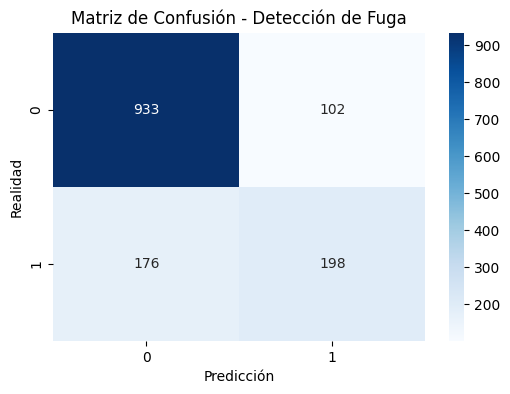

✅ Celda 3 completada: Tu archivo .pkl se guardó en ../Models/pipeline_churn_model.pkl


In [21]:
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Predecir con los datos que el modelo nunca ha visto
y_pred = grid_search.predict(X_test)

# 2. Imprimir métricas profesionales
print("--- 📊 REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

# 3. Dibujar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Detección de Fuga')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# 4. Exportar el modelo
os.makedirs('../Models', exist_ok=True)
ruta_pkl = '../Models/pipeline_churn_model.pkl'
joblib.dump(grid_search.best_estimator_, ruta_pkl)

print(f"✅ Celda 3 completada: Tu archivo .pkl se guardó en {ruta_pkl}")